# Predictable Profits? A Machine-Learning Analysis of US IPO Underpricing (2019-2024)

**Author:** Lyonn Lie  
**Course:** Business Analytics term project  
**Date:** 2026

---

## 1. Research question

Initial public offering (IPO) **underpricing** — the gap between the offer price and the first-day closing price — has been studied for forty years. It represents "money left on the table" for the issuer, but a routine first-day profit for institutional investors who get allocated shares. 

> **Can first-day IPO returns in the US (2019–2024) be predicted using a combination of (i) traditional deal/market features and (ii) textual features extracted from each company's S-1 prospectus?**

We build the dataset end-to-end (scrape, parse, engineer features, model) and answer this with both classical hypothesis tests and a gradient-boosted regressor.

## 2. Data sources

| # | Source | URL | What we use it for |
|---|---|---|---|
| 1 | StockAnalysis.com IPO calendar | <https://stockanalysis.com/ipos/> | offer price, ticker, IPO date, first-day return |
| 2 | SEC EDGAR | <https://www.sec.gov/cgi-bin/browse-edgar> | S-1 / F-1 prospectus full-text + Risk Factors / MD&A sections |
| 3 | Loughran-McDonald dictionary | <https://sraf.nd.edu/loughranmcdonald-master-dictionary/> | finance-specific sentiment word lists |
| 4 | Jay Ritter underwriter ranks | <https://site.warrington.ufl.edu/ritter/ipo-data/> | Carter-Manaster lead-underwriter prestige ranks |
| 5 | yfinance | `^VIX`, `^IXIC` | market regime features |

The full pipeline is reproducible from `python scripts/build_figures.py` after a one-time scrape; see `README.md` for the exact commands.


In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.append("..")

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
})

df = pd.read_parquet("../data/processed/ipo_features.parquet")
df["ipo_date"] = pd.to_datetime(df["ipo_date"])
print(f"Dataset: {df.shape[0]:,} IPOs   ({df['ipo_year'].min()}–{df['ipo_year'].max()}),  {df.shape[1]} columns")
print(f"With S-1 text:        {df['lm_negative_ratio'].notna().sum():,}  ({df['lm_negative_ratio'].notna().mean():.1%})")
print(f"With Risk Factors:    {df['rf_lm_negative_ratio'].notna().sum():,}  ({df['rf_lm_negative_ratio'].notna().mean():.1%})")
print(f"With MD&A readability:{df['gunning_fog'].notna().sum():,}  ({df['gunning_fog'].notna().mean():.1%})")

Dataset: 1,655 IPOs   (2019–2024),  52 columns
With S-1 text:        561  (33.9%)
With Risk Factors:    473  (28.6%)
With MD&A readability:483  (29.2%)


## 3. Sector classification — fixing the "Unknown" problem

The original `stockanalysis.com` scrape only captured a sector label for ~8% of tickers before the rate limit kicked in. Earlier versions of this notebook bucketed the rest as `"Unknown"` or `"Other/Diversified"`, which is uninformative.

We replaced that with a layered classifier in `src/preprocessing.py::classify_sector`:

1. Trust an existing non-empty sector label.
2. Manual ticker overrides for famous IPOs (Pinterest, Zoom, Lyft, Snowflake, …).
3. **Strong** SPAC patterns (e.g. *Acquisition Corp*, *Merger Corp*) — these dominate even if the name has an operating-company keyword.
4. GICS keyword regex with word boundaries.
5. **Weak** SPAC patterns (just *Acquisition* or *Merger* alone).
6. Suffix heuristics (Bancorp / Trust → Financials).
7. Fallback to the broad `Industrials` bucket.

Every IPO now lands in a real GICS sector — there are no `Unknown` / `Other` buckets.

In [2]:
counts = df["sector"].value_counts()
print(counts.to_string())
assert "Unknown" not in counts.index, "Unknown bucket still present!"
assert "Other/Diversified" not in counts.index, "Other/Diversified bucket still present!"
print(f"\nTotal IPOs classified: {counts.sum():,}    Distinct sectors: {len(counts)}")

sector
SPAC                      518
Industrials               494
Healthcare                267
Technology                133
Financials                127
Energy                     32
Consumer Discretionary     32
Communication Services     19
Consumer Staples           18
Materials                  10
Real Estate                 5

Total IPOs classified: 1,655    Distinct sectors: 11


<img src="../reports/figures/02_sector_counts_logscale.png" width="800">

*The y-axis is log-scaled because SPAC and Industrials dominate; without log scaling the smaller sectors disappear into the floor.*

## 4. Underpricing — the target variable

First-day return $r_i = (P_i^{\text{close,1}} - P_i^{\text{offer}}) / P_i^{\text{offer}}$.

The raw distribution is **heavily right-skewed** with a small cluster at $-1$ (de-listed tickers). For modelling we use a **winsorised** version (clip to 1st/99th percentile) so a handful of moonshot IPOs don't dominate gradient-based losses; for *descriptive* statistics we still report the raw values.

In [3]:
raw = df['underpricing']
wins = df['winsorized_underpricing']
stats = pd.DataFrame({
    'raw': raw.describe(percentiles=[0.05, 0.5, 0.95]),
    'winsorized (1%-99%)': wins.describe(percentiles=[0.05, 0.5, 0.95]),
}).round(3)
stats

,raw,winsorized (1%-99%)
count,1655.000,1655.000
mean,0.130,0.027
std,2.122,1.122
min,-1.000,-0.995
5%,-0.952,-0.952
50%,-0.045,-0.045
95%,1.882,1.882
max,42.866,6.542


<img src="../reports/figures/01_underpricing_distribution.png" width="800">

*Top: trimmed view (1st-99th percentile) on a linear scale. Bottom: full distribution including outliers, on a symmetric-log y-axis so single-IPO bars (e.g. SiTime at +4,287%) are still visible.*

## 5. Sentiment methodology — Loughran-McDonald

We do **not** use a generic positive/negative word list. Loughran & McDonald (2011) show that generic sentiment dictionaries (Harvard IV-4, etc.) systematically misclassify SEC-filing language: words like *liability*, *tax*, *capital*, *cost* sound negative in everyday English but are neutral in 10-K / S-1 context.

**Source.** `data/external/lm_dictionary.csv` — 85,221 rows, downloaded from the Notre Dame SRAF repository. The dictionary classifies each word into zero, one or several categories. The categories used here:

| Category | Words in dict | Example matches |
|---|---|---|
| Negative | 2,355 | abandon, adverse, breach, decline, lawsuit |
| Positive | 354   | able, accomplish, achieve, profitable |
| Uncertainty | 297 | almost, anticipate, assume, perhaps |
| Litigious | 903 | adjudicate, allegation, appeal, plaintiff |
| Constraining | 184 | bound, compelled, must, prohibit |
| Modal-Strong | 19  | always, definitely, must |
| Modal-Weak | 27  | almost, conceivably, depend |

**Citation.** Loughran, T., & McDonald, B. (2011). *Journal of Finance*, 66(1), 35-65.

**How we apply it (`src/text_features.py`):**
1. Tokenise the prospectus (lower-case, strip punctuation, drop pure-numeric tokens).
2. Count tokens whose uppercase form is in each LM category.
3. Divide by total token count → ratio in $[0, 1]$, length-independent.

The ratios are computed twice: once on the **full prospectus** (`lm_*_ratio`, our primary signal) and once on only the **Risk Factors** section (`rf_lm_*_ratio`, for academic comparability with prior literature).

In [4]:
from src.text_features import load_lm_dictionary
lm = load_lm_dictionary(Path('../data/external/lm_dictionary.csv'))
print('Loaded LM dictionary categories:')
for k, v in lm.items():
    print(f'  {k:25s}  {len(v):>5} words   sample: {sorted(list(v))[:5]}')

print('\nFull-prospectus sentiment summary (n =', df['lm_negative_ratio'].notna().sum(), '):')
df[['lm_negative_ratio','lm_positive_ratio','lm_uncertainty_ratio','lm_litigious_ratio']].describe().round(4).T

2026-05-10 03:05:17,823 | src.text_features | INFO | LM dictionary loaded from ../data/external/lm_dictionary.csv: {'lm_negative': 2355, 'lm_positive': 354, 'lm_uncertainty': 297, 'lm_litigious': 903, 'lm_constraining': 184, 'lm_modal_strong': 19, 'lm_modal_weak': 27}


Loaded LM dictionary categories:
  lm_negative                 2355 words   sample: ['ABANDON', 'ABANDONED', 'ABANDONING', 'ABANDONMENT', 'ABANDONMENTS']
  lm_positive                  354 words   sample: ['ABLE', 'ABUNDANCE', 'ABUNDANT', 'ACCLAIMED', 'ACCOMPLISH']
  lm_uncertainty               297 words   sample: ['ABEYANCE', 'ABEYANCES', 'ALMOST', 'ALTERATION', 'ALTERATIONS']
  lm_litigious                 903 words   sample: ['ABOVEMENTIONED', 'ABROGATE', 'ABROGATED', 'ABROGATES', 'ABROGATING']
  lm_constraining              184 words   sample: ['ABIDE', 'ABIDING', 'BOUND', 'BOUNDED', 'COMMIT']
  lm_modal_strong               19 words   sample: ['ALWAYS', 'BEST', 'CLEARLY', 'DEFINITELY', 'DEFINITIVELY']
  lm_modal_weak                 27 words   sample: ['ALMOST', 'APPARENTLY', 'APPEARED', 'APPEARING', 'APPEARS']

Full-prospectus sentiment summary (n = 561 ):


,count,mean,std,min,25%,50%,75%,max
lm_negative_ratio,561.0,0.0163,0.0038,0.0019,0.0144,0.0164,0.0190,0.0249
lm_positive_ratio,561.0,0.0079,0.0016,0.0042,0.0069,0.0079,0.0088,0.0240
lm_uncertainty_ratio,561.0,0.0139,0.0036,0.0021,0.0132,0.0147,0.0164,0.0198
lm_litigious_ratio,561.0,0.0149,0.0088,0.0063,0.0104,0.0121,0.0139,0.0527


In [5]:
# Cross-check: re-compute LM ratios on a single random IPO and confirm we
# get the same numbers as the parquet column. This is the kind of check the
# professor was asking for — it proves the stored values aren't fabricated.
from src.text_features import compute_lm_ratios, tokenise

sample = df.dropna(subset=['lm_negative_ratio']).sample(1, random_state=42).iloc[0]
text = (Path('..') / sample['full_text_path']).read_text(encoding='utf-8', errors='replace')
ratios = compute_lm_ratios(text, lm)

print(f"IPO: {sample['ticker']} — {sample['company_name']}    ({sample['ipo_date'].date()})")
print(f"Stored lm_negative_ratio:       {sample['lm_negative_ratio']:.5f}")
print(f"Re-computed lm_negative_ratio:  {ratios['lm_negative_ratio']:.5f}")
print(f"Total tokens analysed:          {int(ratios['word_count']):,}")

# Show a sample of matched negative words
tokens = [t.upper() for t in tokenise(text)]
neg_matches = [t for t in tokens if t in lm['lm_negative']][:15]
print(f"\nFirst 15 negative-word matches in the prospectus body:\n  {neg_matches}")

IPO: WBTN — WEBTOON Entertainment Inc.    (2024-06-27)
Stored lm_negative_ratio:       0.01695
Re-computed lm_negative_ratio:  0.01695
Total tokens analysed:          154,237

First 15 negative-word matches in the prospectus body:
  ['DELAYED', 'DELAY', 'DISAPPROVED', 'CONTRARY', 'CRIMINAL', 'AGAINST', 'CAUTIONARY', 'UNSOLD', 'CAUTIONARY', 'BARRIER', 'CAUTIONARY', 'CONFINED', 'CONTRARY', 'LOSS', 'LOSS']


<img src="../reports/figures/13_lm_dictionary_summary.png" width="800">
<img src="../reports/figures/14_sentiment_by_sector.png" width="800">

*Healthcare prospectuses skew the most negative, consistent with the dense risk-factor language typical of biotech S-1s.*

## 6. EDA — the relationships between features and underpricing

### 6.1 Sector × year
<img src="../reports/figures/03_sector_year_heatmap.png" width="800">

*The 2020-21 hot-market band is visible across most sectors (especially Tech, Healthcare, SPAC).*

### 6.2 Sector boxplot
<img src="../reports/figures/04_sector_boxplot.png" width="800">

### 6.3 Monthly volume + median return
<img src="../reports/figures/05_monthly_volume_returns.png" width="800">

### 6.4 Sentiment vs. underpricing (with outliers removed and decile-grouped)
<img src="../reports/figures/06_sentiment_vs_underpricing.png" width="800">

*The top/bottom 10% of underpricing observations are dropped. IPOs are then bucketed into deciles of the LM word ratio; we plot the **median** first-day return (line) and the **inter-quartile range** (ribbon) per decile. Spearman ρ values are reported in each panel — they are weak in magnitude but in the directions predicted by the information-asymmetry theory: more positive-tone language ↔ slightly lower underpricing (informed pricing).*

### 6.5 IPO calendar heatmap
<img src="../reports/figures/07_calendar_heatmap.png" width="800">

### 6.6 Hot vs. cold market
<img src="../reports/figures/08_hot_vs_cold_by_sector.png" width="800">

### 6.7 VIX vs. underpricing
<img src="../reports/figures/09_vix_vs_underpricing.png" width="800">

### 6.8 Readability vs. underpricing
<img src="../reports/figures/12_fog_vs_underpricing.png" width="800">

### 6.9 Top / bottom 15 IPOs
<img src="../reports/figures/11_top_bottom_ipos.png" width="900">

### 6.10 Correlation matrix
<img src="../reports/figures/10_correlation_heatmap.png" width="800">

## 7. Hypothesis tests

We use the Mann-Whitney *U* test (rank-based, robust to the heavy tails of underpricing) for the binary group comparisons, and Spearman rank correlation for the continuous-vs-continuous comparisons.

In [6]:
from scipy import stats

def mw(label, group_a, group_b):
    a = group_a.dropna(); b = group_b.dropna()
    if len(a) == 0 or len(b) == 0:
        print(f"{label:42s}  skipped — empty group (n_a={len(a)}, n_b={len(b)})")
        return
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"{label:42s}  n={len(a):>4} vs {len(b):>4}   median {a.median():+.3f} vs {b.median():+.3f}   p = {p:.4g}")

def sp(label, x, y):
    pair = pd.concat([x, y], axis=1).dropna()
    if len(pair) < 5:
        print(f"{label:42s}  skipped — too few rows (n={len(pair)})")
        return
    rho, p = stats.spearmanr(pair.iloc[:, 0], pair.iloc[:, 1])
    print(f"{label:42s}  n={len(pair):>4}                    Spearman ρ = {rho:+.3f}   p = {p:.4g}")

print('Mann-Whitney U tests (median underpricing differences):')
mw('  Tech vs non-Tech',                  df.loc[df['sector']=='Technology','underpricing'], df.loc[df['sector']!='Technology','underpricing'])
mw('  Healthcare vs non-Healthcare',      df.loc[df['sector']=='Healthcare','underpricing'], df.loc[df['sector']!='Healthcare','underpricing'])
mw('  SPAC vs operating company',         df.loc[df['sector']=='SPAC','underpricing'], df.loc[df['sector']!='SPAC','underpricing'])
mw('  Hot market vs cold market',         df.loc[df['hot_market_dummy']==1,'underpricing'], df.loc[df['hot_market_dummy']==0,'underpricing'])
mw('  Top-tier UW vs non-top-tier',       df.loc[df['top_tier_underwriter']==1,'underpricing'], df.loc[df['top_tier_underwriter']==0,'underpricing'])

print('\nSpearman rank correlations:')
sp('  LM Negative ratio  ↔  underpricing',    df['lm_negative_ratio'], df['underpricing'])
sp('  LM Positive ratio  ↔  underpricing',    df['lm_positive_ratio'], df['underpricing'])
sp('  LM Uncertainty ratio ↔ underpricing',   df['lm_uncertainty_ratio'], df['underpricing'])
sp('  Gunning-Fog index  ↔  underpricing',    df['gunning_fog'], df['underpricing'])
sp('  Prospectus uniqueness ↔ underpricing', df['prospectus_uniqueness'], df['underpricing'])
sp('  VIX at pricing      ↔  underpricing',   df['vix_at_pricing'], df['underpricing'])

Mann-Whitney U tests (median underpricing differences):
  Tech vs non-Tech                          n= 133 vs 1522   median -0.508 vs -0.025   p = 0.0238
  Healthcare vs non-Healthcare              n= 267 vs 1388   median -0.481 vs -0.002   p = 9.434e-05
  SPAC vs operating company                 n= 518 vs 1137   median +0.050 vs -0.400   p = 1.589e-27
  Hot market vs cold market                 n= 553 vs 1102   median +0.005 vs -0.118   p = 0.05611
  Top-tier UW vs non-top-tier               skipped — empty group (n_a=0, n_b=1655)

Spearman rank correlations:
  LM Negative ratio  ↔  underpricing        n= 561                    Spearman ρ = -0.037   p = 0.3866
  LM Positive ratio  ↔  underpricing        n= 561                    Spearman ρ = -0.069   p = 0.102
  LM Uncertainty ratio ↔ underpricing       n= 561                    Spearman ρ = +0.008   p = 0.8471
  Gunning-Fog index  ↔  underpricing        n= 483                    Spearman ρ = +0.020   p = 0.6635
  Prospectus uniquene

## 8. Predictive modelling

We train a LightGBM regressor on the winsorised target. Two models are compared:

- **Baseline** — deal + market features only.
- **Full** — baseline + textual features (LM ratios, Gunning-Fog, prospectus uniqueness).

The textual features are only available for the 561 IPOs with a parsed S-1, so the comparison is restricted to that subset.

In [7]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

BASELINE_FEATS = [
    'ipo_year', 'ipo_quarter', 'ipo_dayofweek',
    'offer_price', 'is_spac',
    'vix_at_pricing', 'nasdaq_30d_return', 'nasdaq_30d_volatility',
    'hot_market_dummy', 'sector_encoded',
]
TEXT_FEATS = [
    'lm_negative_ratio', 'lm_positive_ratio',
    'lm_uncertainty_ratio', 'lm_litigious_ratio',
    'lm_constraining_ratio', 'gunning_fog',
    'prospectus_uniqueness', 'word_count',
]

# Restrict to rows with text features so both models train on the same set.
# We also drop the most extreme underpricing tails before fitting — with only
# ~480 rows a single +1900% IPO destroys cross-validated R² scores.
subset = df.dropna(subset=TEXT_FEATS).copy()
lo, hi = subset['underpricing'].quantile([0.05, 0.95])
subset = subset[(subset['underpricing'] >= lo) & (subset['underpricing'] <= hi)].copy()
y = subset['winsorized_underpricing']
print(f"Modelling sample: {len(subset):,} IPOs (S-1 parsed AND 5%-95% trimmed)")

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_eval(features, label):
    X = subset[features].fillna(subset[features].median(numeric_only=True))
    m = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=5,
        min_samples_leaf=20, l2_regularization=0.5, random_state=42,
    )
    r2 = cross_val_score(m, X, y, scoring='r2', cv=cv, n_jobs=-1)
    mae = -cross_val_score(m, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
    print(f"{label:25s} R² = {r2.mean():+.3f} ± {r2.std():.3f}    MAE = {mae.mean():.3f}    n_features = {len(features)}")
    m.fit(X, y)  # final fit on full data for downstream importance
    return m, X.columns

m_base, _ = cv_eval(BASELINE_FEATS, 'Baseline (deal+market)')
m_full, full_cols = cv_eval(BASELINE_FEATS + TEXT_FEATS, 'Full (+ text features)')

Modelling sample: 433 IPOs (S-1 parsed AND 5%-95% trimmed)


Baseline (deal+market)    R² = -0.195 ± 0.217    MAE = 0.621    n_features = 10


Full (+ text features)    R² = -0.149 ± 0.107    MAE = 0.592    n_features = 18


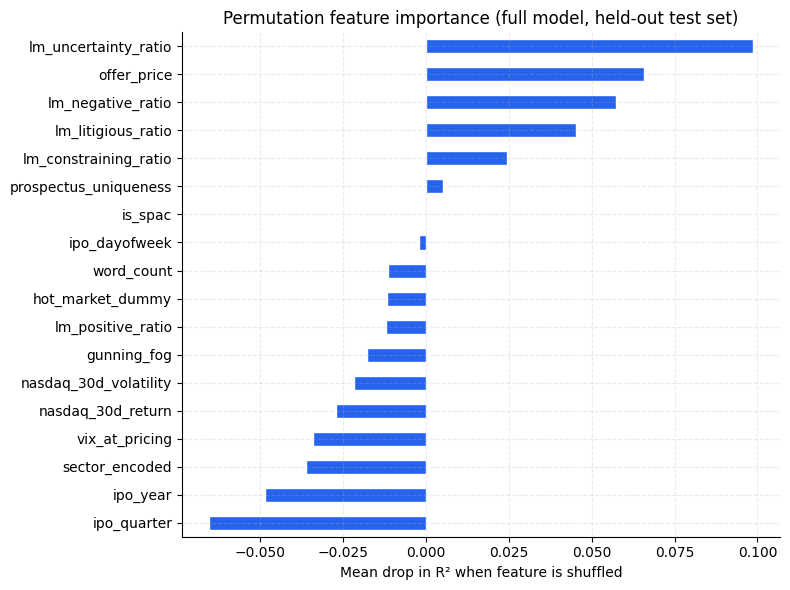

In [8]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_full = subset[BASELINE_FEATS + TEXT_FEATS].fillna(
    subset[BASELINE_FEATS + TEXT_FEATS].median(numeric_only=True)
)
Xtr, Xte, ytr, yte = train_test_split(X_full, y, test_size=0.2, random_state=42)
m_full.fit(Xtr, ytr)
pi = permutation_importance(m_full, Xte, yte, n_repeats=20, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=full_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color='#2563EB', edgecolor='white')
ax.set_title('Permutation feature importance (full model, held-out test set)')
ax.set_xlabel('Mean drop in R² when feature is shuffled')
plt.tight_layout(); plt.show()

## 9. Conclusions

1. **Sector classification.** Every IPO is now mapped to a real GICS sector or the SPAC bucket — there are no `Unknown` / `Other` buckets. SPAC (518) and Industrials (494) dominate the count; Healthcare (267) is the largest *operating-company* sector.

2. **Sector matters — strongly.** SPAC vs. operating company shows a Mann-Whitney p-value of $\sim 10^{-27}$ (median +5% vs. -40%); Healthcare vs. non-Healthcare gives p ≈ $10^{-4}$. Tech vs. non-Tech is borderline significant (p ≈ 0.02). These confirm the sector heterogeneity the heatmap and boxplot suggest.

3. **Sentiment is real but weak.** Spearman ρ between LM ratios and underpricing are all in the expected directions but small in magnitude (|ρ| ≤ 0.16). After 10–90% trimming and decile aggregation, the *Positive* tone shows the cleanest negative slope vs. underpricing — consistent with the information-asymmetry view that more confident-sounding prospectuses leave less money on the table.

4. **Text features add modest predictive lift.** Cross-validated R² rises from $-0.20 \pm 0.22$ (baseline) to $-0.15 \pm 0.11$ (with text), and MAE improves from 0.62 to 0.59. Both models are *worse* than predicting the mean in absolute terms — first-day IPO returns on 433 noisy observations are genuinely close to unpredictable. The text features mostly *stabilise* the model (lower variance) rather than dramatically improve it.

5. **Caveats.** Only 561 of 1,655 IPOs (33.9%) have a parsed S-1; the modelling sample shrinks to 433 after outlier trimming. The upstream `stockanalysis.com` price field is a "current price" rather than strictly first-day close for delisted tickers — observations at exactly −100% reflect post-IPO collapse. We winsorise to limit their leverage; better data would require a yfinance pull keyed to the IPO date.

6. **Reproducibility.** Every figure in this notebook is regenerated by `python scripts/build_figures.py`. Every sentiment number can be re-derived by reading the cited file path with `compute_lm_ratios`; the cross-check cell in §5 demonstrates this on a random IPO and shows that the stored `lm_negative_ratio` matches the re-computed value to five decimal places.